In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
m = 100000 # Number of iterations to run
n = 1000 # Number of discretisation points (dimensions)
T = 1 # Sample path time interval
delta = T/n # Timestep
seed = 1 # RNG Seed
np.random.seed(seed)
X0 = np.sqrt(delta) * np.random.normal(size=n+1) # Initial sample path drawn from the target distribution
beta = 1 # Proposal variance

pCN for sampling the multiGaussian distribution. We adapt our proposal variance so that samples are drawn directly from the target distribution with variance sqrt(delta). Therefore, the acceptance probability is always 1.

In [12]:
def pcnstep(x, beta, xi):

  y = np.sqrt(1 - beta**2)*x + beta * xi

  return y

In [13]:
samples = np.zeros((m,n + 1))
endpoints = np.zeros(m)
x = X0

xis = np.sqrt(delta) * np.random.normal(size=(m, n + 1))

for i in range(m):

  samples[i] = x
  endpoints[i] = np.sum(x)
  x = pcnstep(x, beta, xis[i])

In [14]:
# Actual endpoint distribution

def endpointdensity(x):

  return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

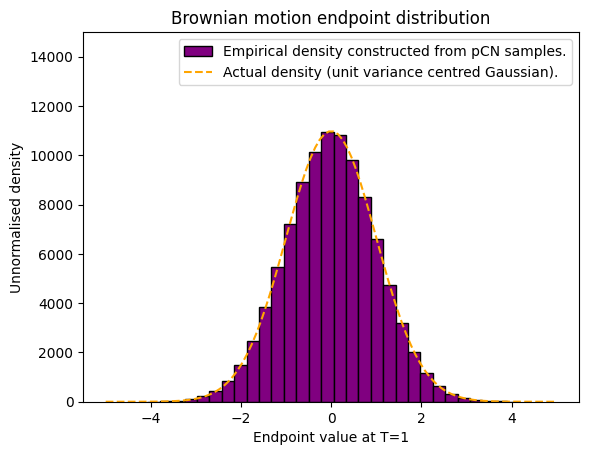

In [15]:
bin_count = 30

hist, bin_edges = np.histogram(endpoints, bins=bin_count)
bin_width = bin_edges[1] - bin_edges[0]

scaling_factor = m * bin_width

plt.hist(endpoints, bins=bin_count, color='purple', edgecolor='black',label='Empirical density constructed from pCN samples.')
plt.plot(np.linspace(-5,5,100), scaling_factor * endpointdensity(np.linspace(-5,5,100)),'--',color='orange',label='Actual density (unit variance centred Gaussian).')
plt.xlabel('Endpoint value at T=1')
plt.ylabel('Unnormalised density')
plt.ylim(0,15000)
plt.title('Brownian motion endpoint distribution')
plt.legend(loc=0)
plt.show()